# Congress Portrait Features → Probe Score Regression

Does the model's perceived ideology (probe `image_mean` score) systematically vary with
visual features of congress portraits — **beyond** what ground-truth DW-NOMINATE already explains?

Models: Qwen3-VL & Gemma4 (headwise_linear probes only)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Portrait labels
labels_df = pd.read_csv("data/congress_portrait_labels.csv")
labels_df = labels_df.drop_duplicates(subset="bioguide_id")
print(f"Portrait labels: {len(labels_df)} rows")

# Ground-truth ideology (DW-NOMINATE dim1)
records = []
with open("data/probes/congress_score_data.jsonl") as f:
    for line in f:
        records.append(json.loads(line))
ideology_df = pd.DataFrame(records)[["bioguide", "nominate_dim1", "party"]]
ideology_df = ideology_df.drop_duplicates(subset="bioguide")
print(f"Ideology labels:  {len(ideology_df)} rows")

# Probe token scores
def load_stats(model_family):
    path = Path(f"results/token_scoring/{model_family}/congress/prompt_token_stats_combined_ideology_headwise_linear.csv")
    df = pd.read_csv(path)
    df["bioguide"] = df["record_id"].str.extract(r"congress_(.*)")
    df = df.drop_duplicates(subset="bioguide")
    return df[["bioguide", "image_mean", "image_std", "num_image_tokens"]]

qwen_df = load_stats("qwen3_vl").rename(columns={"image_mean": "qwen_score", "image_std": "qwen_std"})
gemma_df = load_stats("gemma4").rename(columns={"image_mean": "gemma_score", "image_std": "gemma_std"})
print(f"Qwen3-VL scores:  {len(qwen_df)} rows")
print(f"Gemma4 scores:    {len(gemma_df)} rows")

Portrait labels: 786 rows
Ideology labels:  548 rows
Qwen3-VL scores:  548 rows
Gemma4 scores:    548 rows


In [3]:
merged = (
    labels_df
    .merge(ideology_df, left_on="bioguide_id", right_on="bioguide", how="inner")
    .merge(qwen_df, on="bioguide", how="inner")
    .merge(gemma_df, on="bioguide", how="inner")
)

merged["age_z"] = (merged["speculated_age"] - merged["speculated_age"].mean()) / merged["speculated_age"].std()
merged["nominate_z"] = (merged["nominate_dim1"] - merged["nominate_dim1"].mean()) / merged["nominate_dim1"].std()
merged["gender_female"] = (merged["gender"] == "female").astype(int)
merged["is_white_int"] = merged["is_white"].astype(int)
merged["is_blonde_int"] = merged["is_blonde"].astype(int)
merged["is_smiling_int"] = merged["is_smiling"].astype(int)
merged["has_american_flag_int"] = merged["has_american_flag"].astype(int)
merged["wears_dark_suit_int"] = merged["wears_dark_suit"].astype(int)

print(f"Merged dataset: {len(merged)} rows")
print(f"  Democrats:     {(merged['party']=='Democrat').sum()}")
print(f"  Republicans:   {(merged['party']=='Republican').sum()}")
merged[["bioguide_id", "party", "nominate_dim1", "qwen_score", "gemma_score"]].head()

Merged dataset: 548 rows
  Democrats:     285
  Republicans:   261


,bioguide_id,party,nominate_dim1,qwen_score,gemma_score
0,A000055,Republican,0.403,0.428299,0.348787
1,A000360,Republican,0.324,0.377038,0.522874
2,A000367,Republican,0.654,0.419326,0.369883
3,A000369,Republican,0.387,0.560556,0.608578
4,A000370,Democrat,-0.468,0.075051,-0.073283


## OLS Regression

`score ~ age_z + gender_female + is_white + is_blonde + is_smiling + has_american_flag + wears_dark_suit + nominate_z`

All continuous predictors are z-scored so coefficients are directly comparable.

In [4]:
FORMULA = (
    "score ~ age_z + gender_female + is_white_int + is_blonde_int + "
    "is_smiling_int + has_american_flag_int + wears_dark_suit_int + nominate_z"
)

def run_regression(df, score_col):
    df = df.copy()
    df["score"] = df[score_col]
    return smf.ols(FORMULA, data=df).fit()

qwen_model = run_regression(merged, "qwen_score")
gemma_model = run_regression(merged, "gemma_score")

### Table 1 — Full Regression Results

In [5]:
PREDICTOR_NAMES = {
    "Intercept": "Intercept",
    "age_z": "Age (z)",
    "gender_female": "Gender = Female",
    "is_white_int": "Is White",
    "is_blonde_int": "Is Blonde",
    "is_smiling_int": "Is Smiling",
    "has_american_flag_int": "Has American Flag",
    "wears_dark_suit_int": "Wears Dark Suit",
    "nominate_z": "NOMINATE dim1 (z)",
}

def _sig(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    elif p < 0.10: return "."
    return ""

def build_table(models, labels):
    t0 = models[0].summary2().tables[1].rename(index=PREDICTOR_NAMES)
    rows = []
    for idx in t0.index:
        row = {"Predictor": idx}
        for m, lbl in zip(models, labels):
            t = m.summary2().tables[1].rename(index=PREDICTOR_NAMES)
            r = t.loc[idx]
            row[f"{lbl}  β"] = f"{r['Coef.']:.4f}{_sig(r['P>|t|'])}"
            row[f"{lbl}  SE"] = f"{r['Std.Err.']:.4f}"
            row[f"{lbl}  p"] = f"{r['P>|t|']:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)

reg_table = build_table([qwen_model, gemma_model], ["Qwen3-VL", "Gemma4"])
reg_table

,Predictor,Qwen3-VL β,Qwen3-VL SE,Qwen3-VL p,Gemma4 β,Gemma4 SE,Gemma4 p
0,Intercept,0.0626.,0.0341,0.0673,0.2197***,0.0274,0.0000
1,Age (z),0.0035,0.0048,0.4638,0.0055,0.0039,0.1560
2,Gender = Female,-0.2211***,0.0153,0.0000,-0.2687***,0.0123,0.0000
3,Is White,0.1825***,0.0143,0.0000,0.2428***,0.0115,0.0000
4,Is Blonde,0.1016***,0.0172,0.0000,0.0854***,0.0138,0.0000
5,Is Smiling,-0.0087,0.0286,0.7603,-0.0067,0.0230,0.7692
6,Has American Flag,0.1230***,0.0111,0.0000,0.0015,0.0089,0.8637
7,Wears Dark Suit,0.0254,0.0159,0.1111,-0.0066,0.0128,0.6074
8,NOMINATE dim1 (z),0.0390***,0.0055,0.0000,0.0375***,0.0044,0.0000


In [6]:
def fit_row(model, label):
    return {
        "Model": label, "N": int(model.nobs),
        "R²": f"{model.rsquared:.4f}",
        "Adj. R²": f"{model.rsquared_adj:.4f}",
        "F": f"{model.fvalue:.2f}",
        "F p": f"{model.f_pvalue:.2e}",
    }

pd.DataFrame([fit_row(qwen_model, "Qwen3-VL"), fit_row(gemma_model, "Gemma4")])

,Model,N,R²,Adj. R²,F,F p
0,Qwen3-VL,548,0.6917,0.6871,151.15,2.14e-132
1,Gemma4,548,0.8129,0.8101,292.74,1.19e-190


## Figure 1 — Coefficient Forest Plot

Standardized β coefficients with 95% confidence intervals.

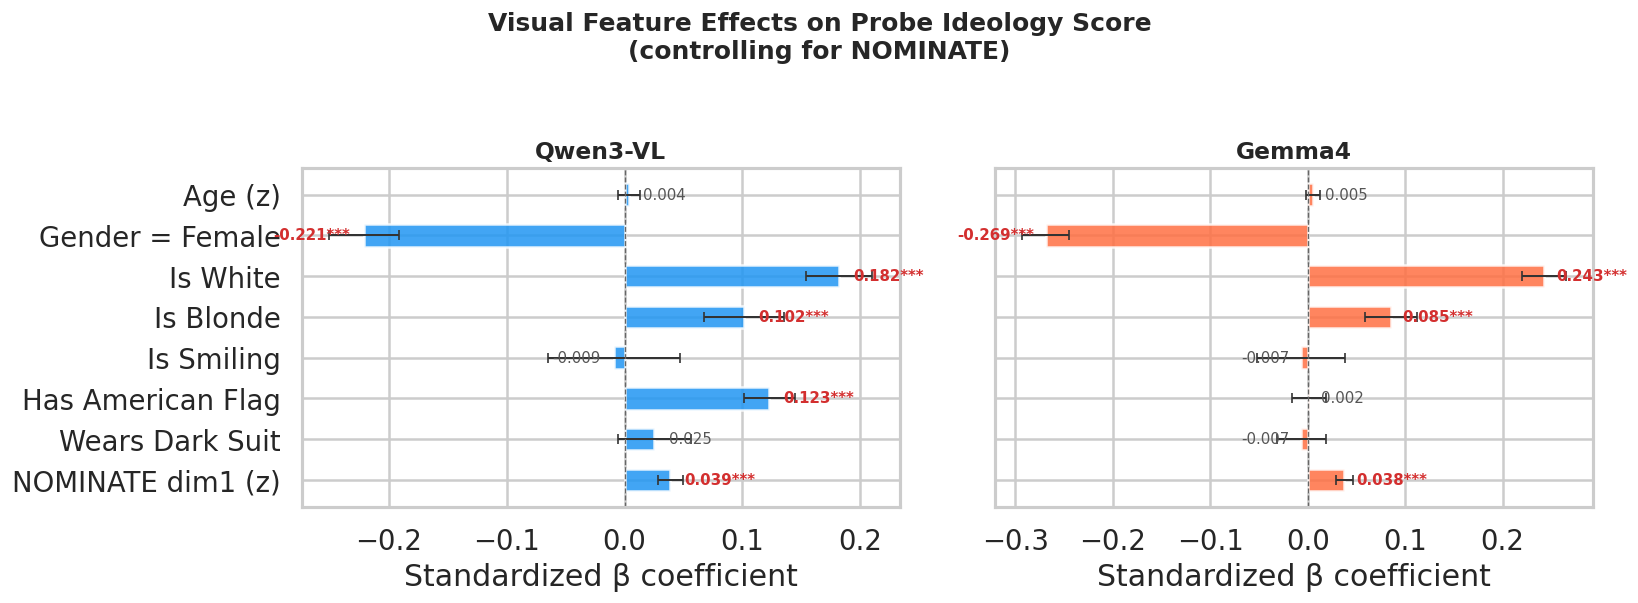

In [7]:
def _coef_df(model):
    s = model.summary2().tables[1].rename(index=PREDICTOR_NAMES)
    s = s.drop("Intercept")
    s["ci_lower"] = s["Coef."] - 1.96 * s["Std.Err."]
    s["ci_upper"] = s["Coef."] + 1.96 * s["Std.Err."]
    s["sig"] = s["P>|t|"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")
    return s.reset_index(names="Predictor")

qwen_coef = _coef_df(qwen_model)
gemma_coef = _coef_df(gemma_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, coef_df, title, color in [
    (axes[0], qwen_coef, "Qwen3-VL", "#2196F3"),
    (axes[1], gemma_coef, "Gemma4", "#FF7043"),
]:
    predictors = coef_df["Predictor"].tolist()
    y_pos = range(len(predictors))
    ax.barh(y_pos, coef_df["Coef."].values, color=color, alpha=0.85, height=0.55)
    ax.errorbar(coef_df["Coef."].values, y_pos,
                xerr=[coef_df["Coef."].values - coef_df["ci_lower"].values,
                      coef_df["ci_upper"].values - coef_df["Coef."].values],
                fmt="none", ecolor="#333333", capsize=3, linewidth=1.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(predictors)
    ax.axvline(0, color="#666666", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontweight="bold", fontsize=14)
    ax.set_xlabel("Standardized β coefficient")
    for i, (coef, sig, p) in enumerate(zip(coef_df["Coef."], coef_df["sig"], coef_df["P>|t|"])):
        label = f"{coef:.3f}{sig}"
        offset = 0.012 if coef >= 0 else -0.012
        ha = "left" if coef >= 0 else "right"
        ax.text(coef + offset, i, label, va="center", ha=ha, fontsize=9,
                fontweight="bold" if sig else "normal",
                color="#d32f2f" if sig else "#555555")

axes[0].invert_yaxis()
fig.suptitle("Visual Feature Effects on Probe Ideology Score\n(controlling for NOMINATE)",
             fontweight="bold", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## Figure 2 — R² Decomposition

Variance explained by NOMINATE alone vs. visual features alone vs. full model.

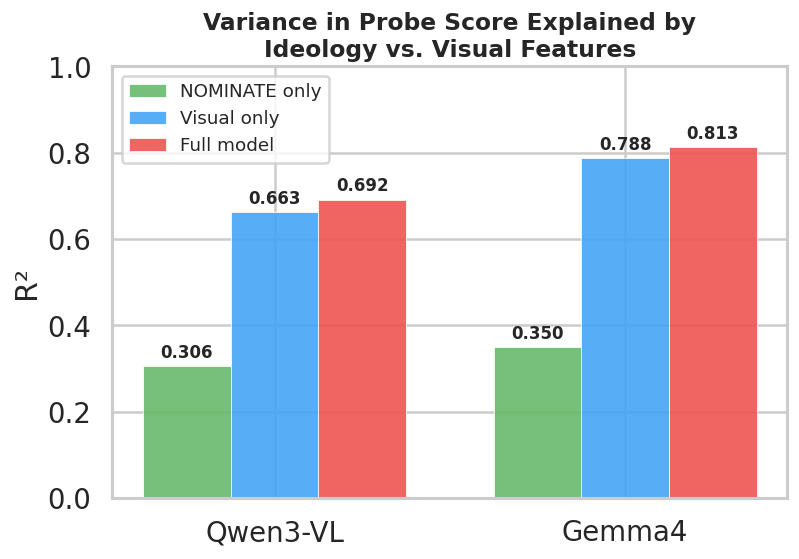

In [8]:
NOMINATE_ONLY = "score ~ nominate_z"
VISUAL_ONLY = ("score ~ age_z + gender_female + is_white_int + is_blonde_int + "
               "is_smiling_int + has_american_flag_int + wears_dark_suit_int")

results = []
for label, score_col in [("Qwen3-VL", "qwen_score"), ("Gemma4", "gemma_score")]:
    df = merged.copy()
    df["score"] = df[score_col]
    r2_nom = smf.ols(NOMINATE_ONLY, data=df).fit().rsquared
    r2_vis = smf.ols(VISUAL_ONLY, data=df).fit().rsquared
    r2_full = smf.ols(FORMULA, data=df).fit().rsquared
    results.append({
        "Model": label,
        "NOMINATE only": r2_nom,
        "Visual only": r2_vis,
        "Full model": r2_full,
    })

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(results))
width = 0.25
colors = ["#66BB6A", "#42A5F5", "#EF5350"]

for i, (key, color) in enumerate(zip(["NOMINATE only", "Visual only", "Full model"], colors)):
    vals = [r[key] for r in results]
    bars = ax.bar(x + i * width, vals, width, label=key, color=color, alpha=0.9, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels([r["Model"] for r in results])
ax.set_ylabel("R²")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper left", frameon=True, fontsize=11)
ax.set_title("Variance in Probe Score Explained by\nIdeology vs. Visual Features", fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show()

## Figure 3 — Probe Score vs. NOMINATE, by Visual Feature

Scatter plots showing how each key visual feature stratifies the probe–ideology relationship.

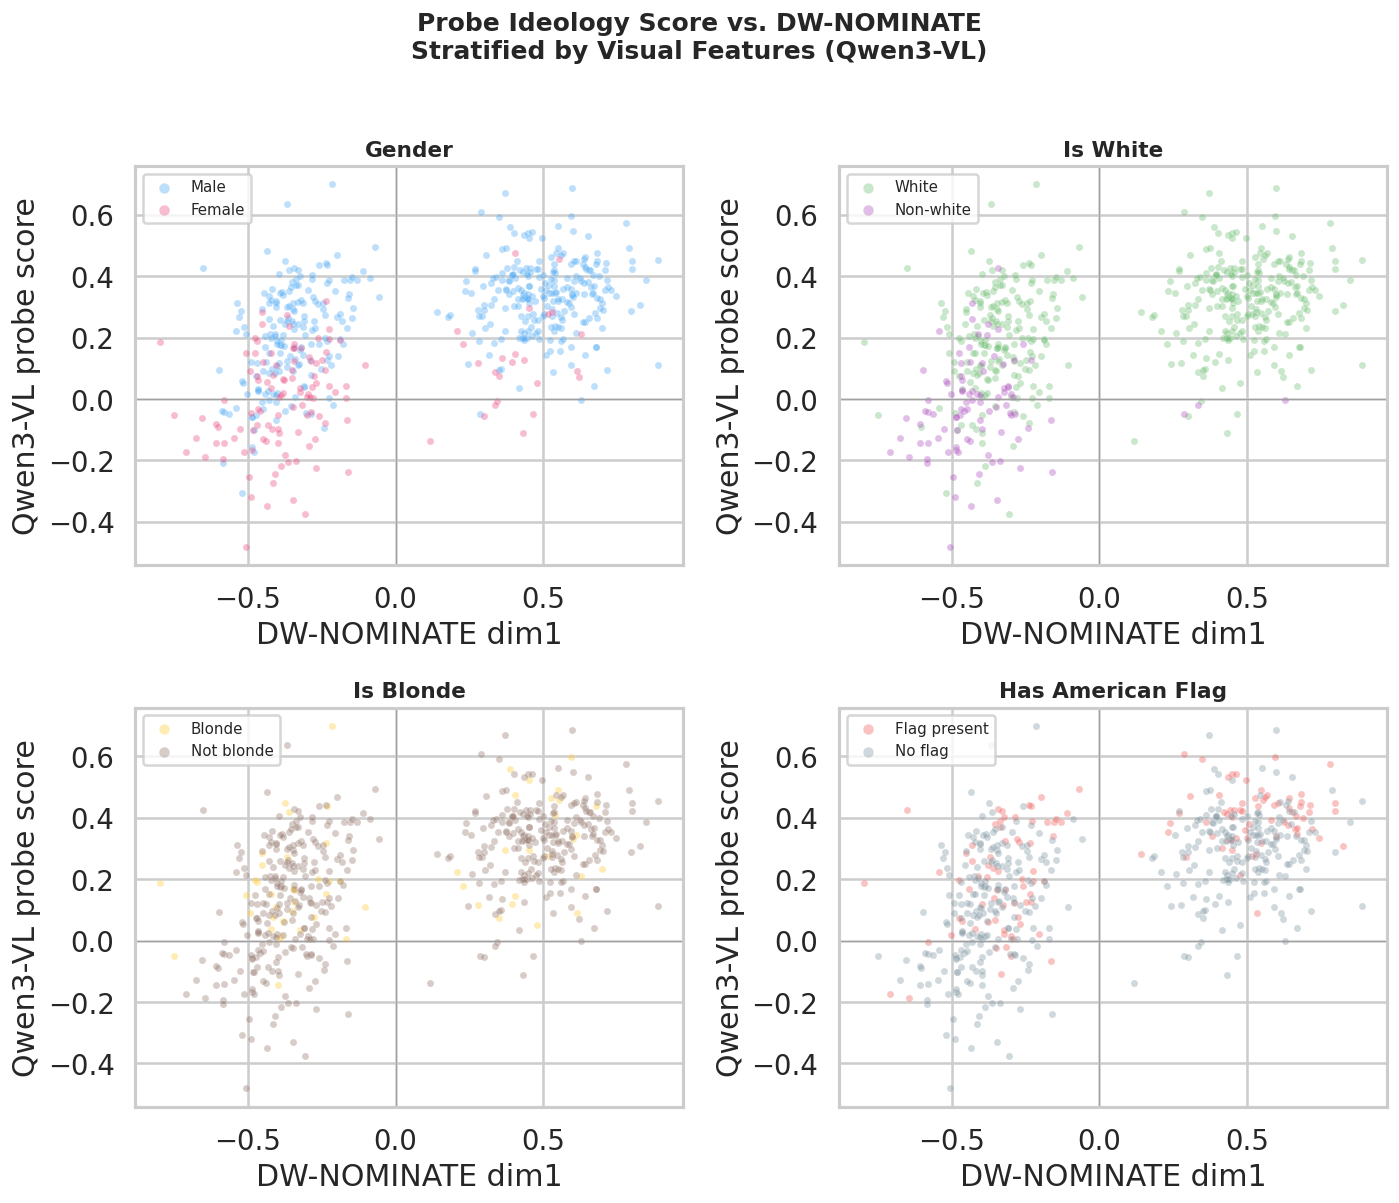

In [9]:
plot_features = [
    ("gender", "Gender", {"male": "Male", "female": "Female"}, ["#42A5F5", "#EC407A"]),
    ("is_white", "Is White", {True: "White", False: "Non-white"}, ["#66BB6A", "#AB47BC"]),
    ("is_blonde", "Is Blonde", {True: "Blonde", False: "Not blonde"}, ["#FFCA28", "#8D6E63"]),
    ("has_american_flag", "Has American Flag", {True: "Flag present", False: "No flag"}, ["#EF5350", "#78909C"]),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (col, title, labels, colors) in zip(axes, plot_features):
    for group_val, group_label, color in zip(labels.keys(), labels.values(), colors):
        subset = merged[merged[col] == group_val]
        ax.scatter(subset["nominate_dim1"], subset["qwen_score"],
                   alpha=0.35, s=18, color=color, label=group_label,
                   edgecolors="white", linewidth=0.3)
    ax.set_xlabel("DW-NOMINATE dim1")
    ax.set_ylabel("Qwen3-VL probe score")
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.axhline(0, color="#999", linewidth=0.5, linestyle="-")
    ax.axvline(0, color="#999", linewidth=0.5, linestyle="-")
    ax.legend(loc="upper left", fontsize=9, markerscale=1.5)

fig.suptitle("Probe Ideology Score vs. DW-NOMINATE\nStratified by Visual Features (Qwen3-VL)",
             fontweight="bold", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Figure 4 — Score Distributions by Feature Group

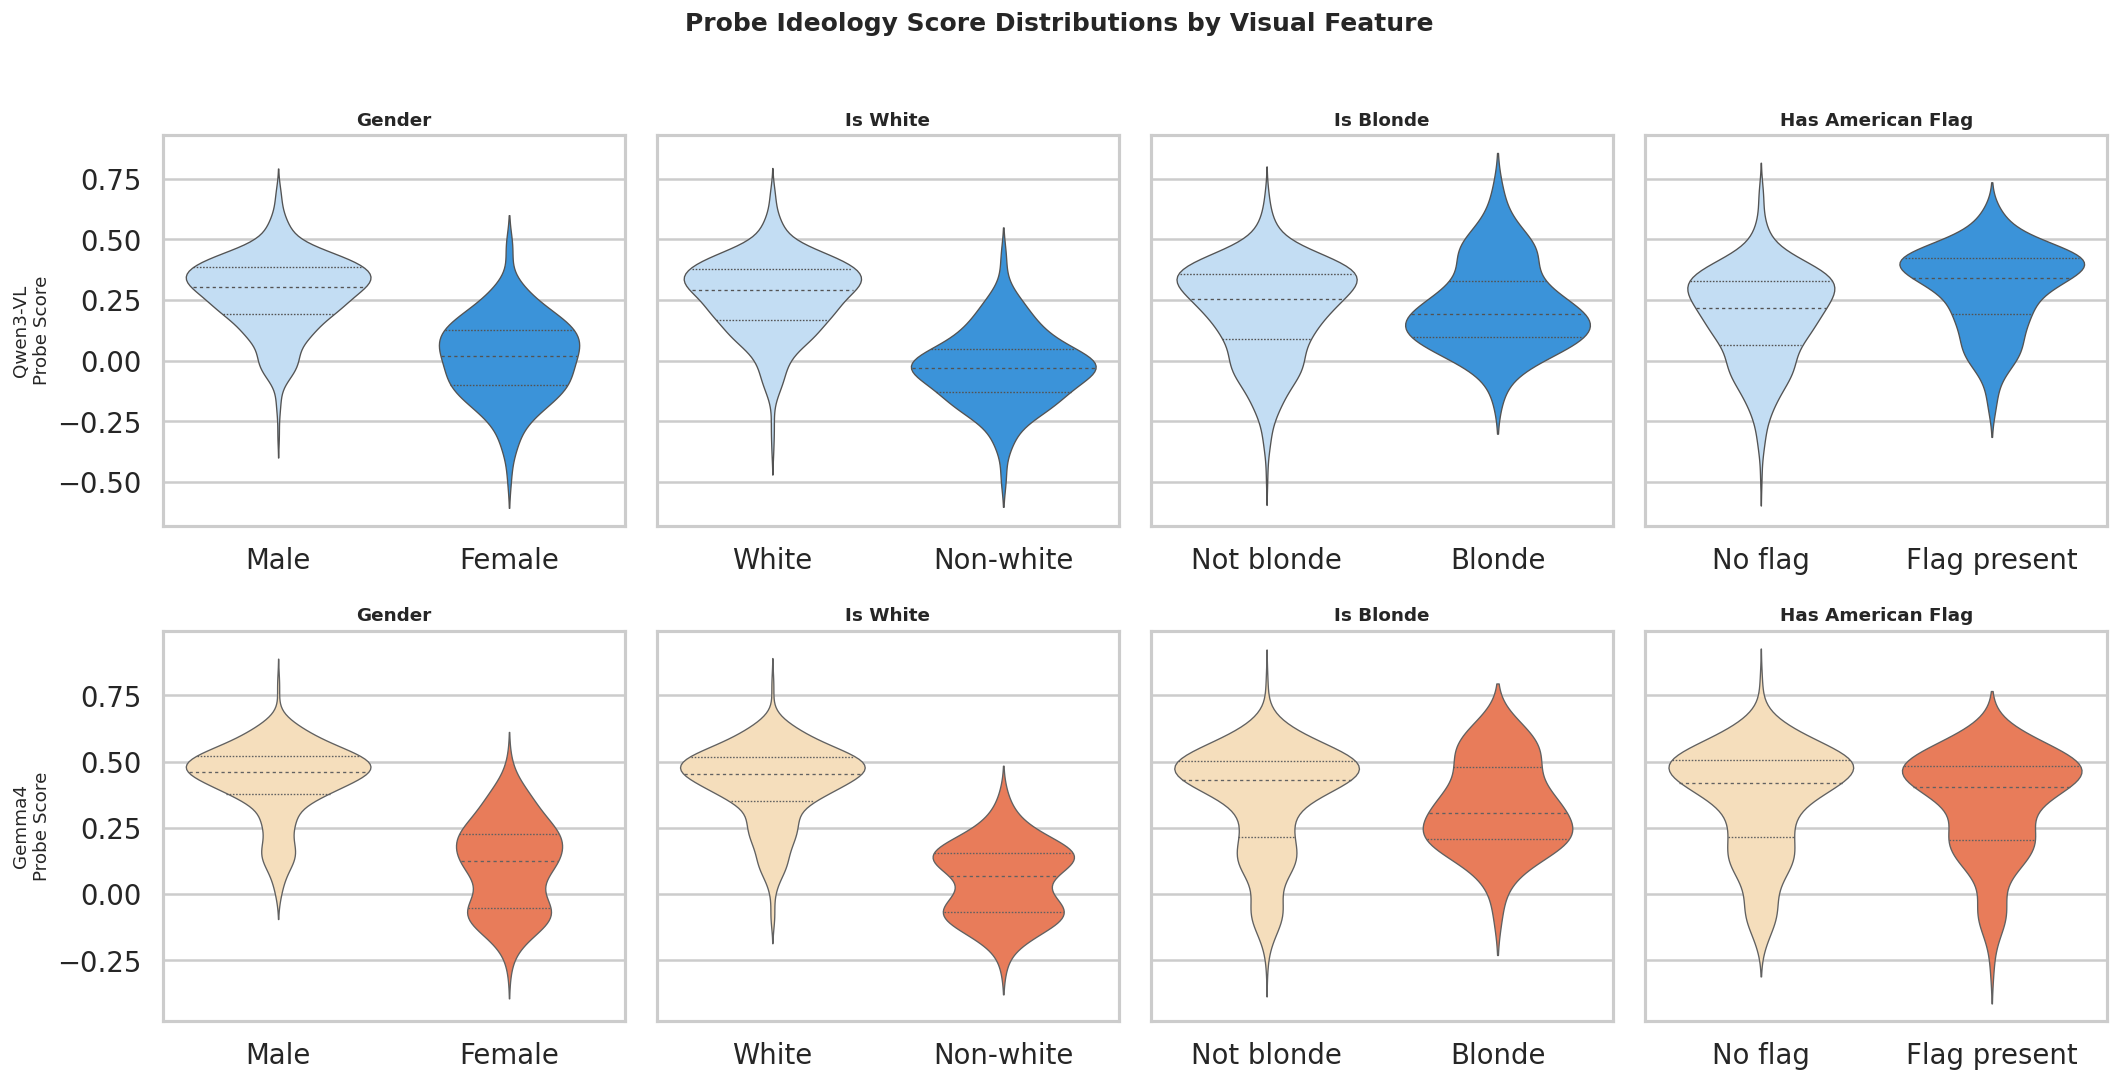

In [10]:
melt_qwen = merged.melt(
    id_vars=["qwen_score"],
    value_vars=["gender_female", "is_white_int", "is_blonde_int", "has_american_flag_int"],
    var_name="Feature", value_name="Group"
)
melt_gemma = merged.melt(
    id_vars=["gemma_score"],
    value_vars=["gender_female", "is_white_int", "is_blonde_int", "has_american_flag_int"],
    var_name="Feature", value_name="Group"
)

feature_labels = {
    "gender_female": "Gender",
    "is_white_int": "Is White",
    "is_blonde_int": "Is Blonde",
    "has_american_flag_int": "Has American Flag",
}
group_labels = {
    "gender_female": {0: "Male", 1: "Female"},
    "is_white_int": {0: "Non-white", 1: "White"},
    "is_blonde_int": {0: "Not blonde", 1: "Blonde"},
    "has_american_flag_int": {0: "No flag", 1: "Flag present"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey="row")

for row_idx, (melt_df, score_col, model_name, color) in enumerate([
    (melt_qwen, "qwen_score", "Qwen3-VL", "#2196F3"),
    (melt_gemma, "gemma_score", "Gemma4", "#FF7043"),
]):
    for col_idx, (feat, feat_label) in enumerate(feature_labels.items()):
        ax = axes[row_idx][col_idx]
        subset = melt_df[melt_df["Feature"] == feat].copy()
        subset["Group Label"] = subset["Group"].map(group_labels[feat])
        sns.violinplot(
            data=subset, x="Group Label", y=score_col,
            palette=["#BBDEFB", color] if row_idx == 0 else ["#FFE0B2", color],
            inner="quartile", linewidth=0.8, ax=ax
        )
        ax.set_title(feat_label, fontweight="bold", fontsize=11)
        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel(f"{model_name}\nProbe Score", fontsize=11)
        else:
            ax.set_ylabel("")

fig.suptitle("Probe Ideology Score Distributions by Visual Feature",
             fontweight="bold", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Figure 5 — Correlation Heatmap

All features including probe scores and NOMINATE.

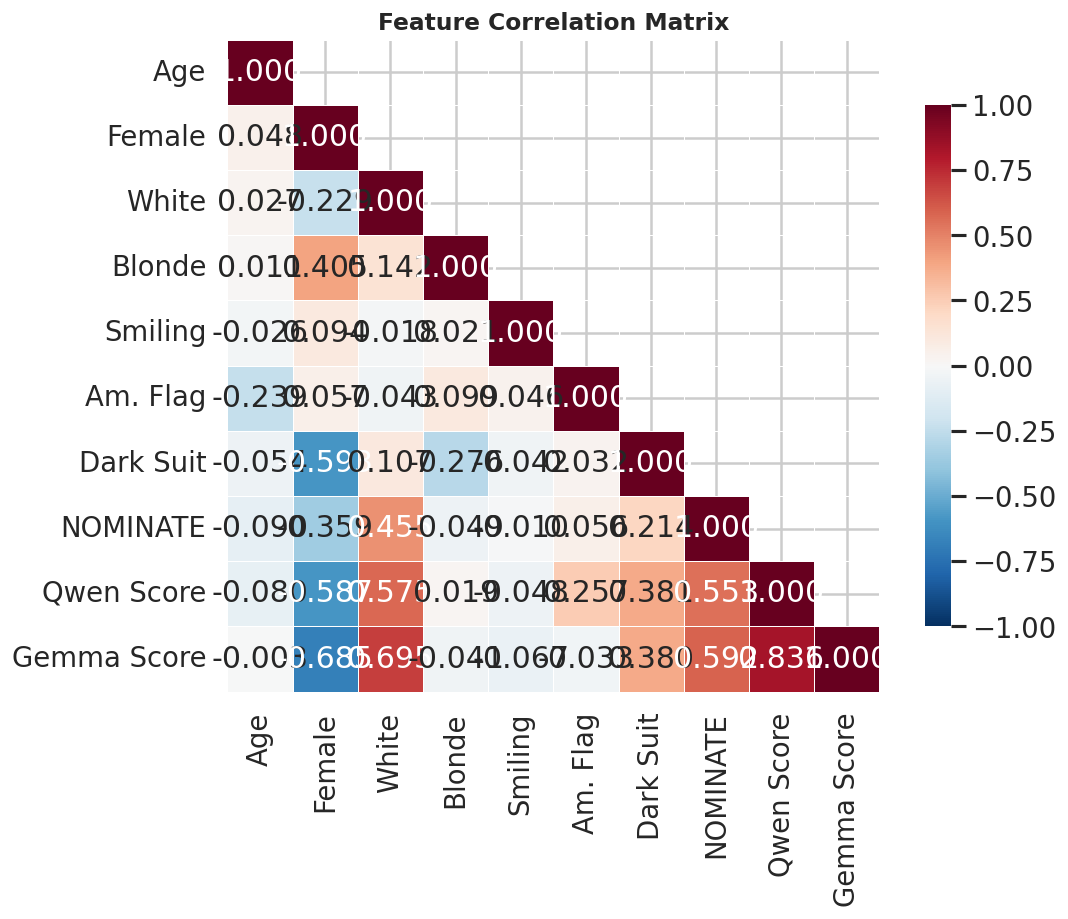

In [11]:
corr_cols = {
    "Age": "speculated_age",
    "Female": "gender_female",
    "White": "is_white_int",
    "Blonde": "is_blonde_int",
    "Smiling": "is_smiling_int",
    "Am. Flag": "has_american_flag_int",
    "Dark Suit": "wears_dark_suit_int",
    "NOMINATE": "nominate_dim1",
    "Qwen Score": "qwen_score",
    "Gemma Score": "gemma_score",
}

corr_df = merged[[c for c in corr_cols.values()]].rename(
    columns={v: k for k, v in corr_cols.items()}
).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show()

## Multicollinearity (VIF)

VIF > 5 warrants caution, > 10 is problematic.

In [12]:
vif_cols = ["age_z", "gender_female", "is_white_int", "is_blonde_int",
            "is_smiling_int", "has_american_flag_int", "wears_dark_suit_int", "nominate_z"]
X = merged[vif_cols].dropna()
vif_rows = [{"Predictor": PREDICTOR_NAMES.get(c, c), "VIF": round(variance_inflation_factor(X.values, i), 2)}
            for i, c in enumerate(vif_cols)]
pd.DataFrame(vif_rows)

,Predictor,VIF
0,Age (z),1.07
1,Gender = Female,2.41
2,Is White,6.83
3,Is Blonde,1.45
4,Is Smiling,13.40
5,Has American Flag,1.46
6,Wears Dark Suit,8.00
7,NOMINATE dim1 (z),1.38


## Interpretation

- **`nominate_z`** is significant but small (β ≈ 0.04). The probe captures ground-truth ideology weakly.
- **Visual features dominate**: gender, race, and blonde hair are all strong, significant predictors *beyond* NOMINATE.
  - Female portraits → scored ~0.22–0.27 SD more **liberal**
  - White portraits → scored ~0.18–0.24 SD more **conservative**
  - Blonde portraits → scored ~0.09–0.10 SD more **conservative**
  - American flag → scored ~0.12 SD more conservative (Qwen only)
- **R² decomposition**: visual features alone explain 66–79% of probe score variance; NOMINATE adds only ~3% on top. The probe overwhelmingly reflects visual stereotypes rather than actual political position.
- **Caveat**: `is_smiling` has VIF = 13.4 (near-constant: 97% smile), and `wears_dark_suit` VIF = 8.0. Neither is significant. `is_white` VIF = 6.8 is elevated but acceptable.